# Автокореляція

In [1]:
# import os
# os.environ['MKL_ENABLE_INSTRUCTIONS'] = 'SSE4_2'

import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

**Кореляція** — це статистичний взаємозв'язок між двома або більше величинами, при якому зміна однієї супроводжується систематичною зміною іншої. Вона показує наявність залежності, але не доводить причинно-наслідкового зв'язку (одне не завжди спричиняє інше). Кореляція буває позитивною (одночасне зростання) або негативною (одна зростає, інша — зменшується).


Коефіцієнт кореляції: Вимірює силу та напрямок зв'язку, зазвичай варіюється від +1 до -1.

Для двох змінних $x,y$, що містять по $N$ величин кожна

$$\rho = \frac{\sum_i (x_i - \mu_x) (y_i - \mu_y)}
{N\sigma_x \sigma_y}$$

$\mu_x, \mu_y$ - середні значення величин

$\sigma_x, \sigma_y$ - їх стандартні відхилення

Щоб дослідити послідовну кореляцію сигналів, почнемо з синусоїди частотою 440 Гц.

In [2]:
from thinkdsp import SinSignal

def make_sine(offset):
    signal = SinSignal(freq=440, offset=offset)
    wave = signal.make_wave(duration=0.5, framerate=10000)
    return wave

Створімо два вейви із різним фазовим зсувом

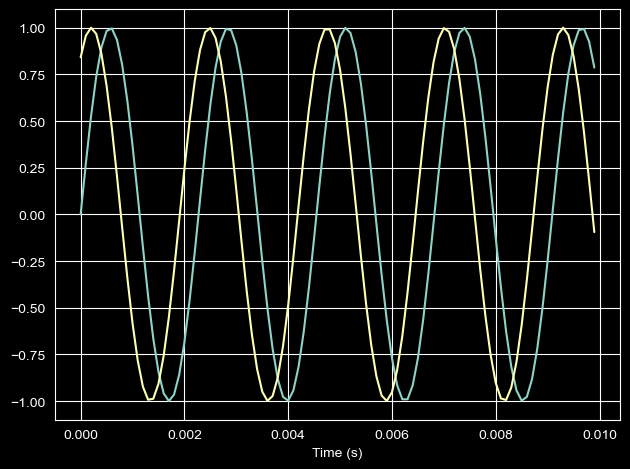

In [3]:
wave1 = make_sine(offset=0)
wave2 = make_sine(offset=1)

wave1.segment(duration=0.01).plot()
wave2.segment(duration=0.01).plot()
decorate(xlabel='Time (s)')

Дві хвилі здаються корельованими: коли одна висока, інша зазвичай також висока.
Ми можемо використовувати `np.corrcoef` для обчислення матриці кореляції.

In [4]:
print(np.corrcoef(wave1.ys, wave2.ys))

[[1.         0.54030231]
 [0.54030231 1.        ]]


Діагональні елементи – це кореляції хвиль із собою, тому вони, природно, дорівнюють 1.
Позадіагональні елементи – це кореляції між двома хвилями. У цьому випадку 0,54 вказує на наявність помірної кореляції між цими хвилями.

Матриця кореляції є цікавішою, коли хвиль більше двох. Якщо хвиль лише дві, то в матриці нас цікавить лише одне число.

Клас ` Wave` має метод `corr`, який обчислює кореляцію між хвилями:

In [5]:
wave1.corr(wave2)

np.float64(0.5403023058681399)

Щоб дослідити зв'язок між фазовим зміщенням та кореляцією, створимо інтерактивну функцію, яка обчислює кореляцію для кожного зміщення:

In [6]:
def compute_corr(offset):
    wave1 = make_sine(offset=0)
    wave2 = make_sine(offset=-offset)

    wave1.segment(duration=0.01).plot()
    wave2.segment(duration=0.01).plot()
    
    corr = wave1.corr(wave2)
    print('corr =', corr)
    
    decorate(xlabel='Time (s)')

Наступна інтерактивна функція відображає хвилі з різними фазовими зміщеннями та друкує їхні кореляції:

In [7]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

PI2 = np.pi * 2
slider = widgets.FloatSlider(min=0, max=PI2, value=1)
interact(compute_corr, offset=slider);

interactive(children=(FloatSlider(value=1.0, description='offset', max=6.283185307179586), Output()), _dom_cla…

Нарешті, ми можемо побудувати графік кореляції як функції зміщення:

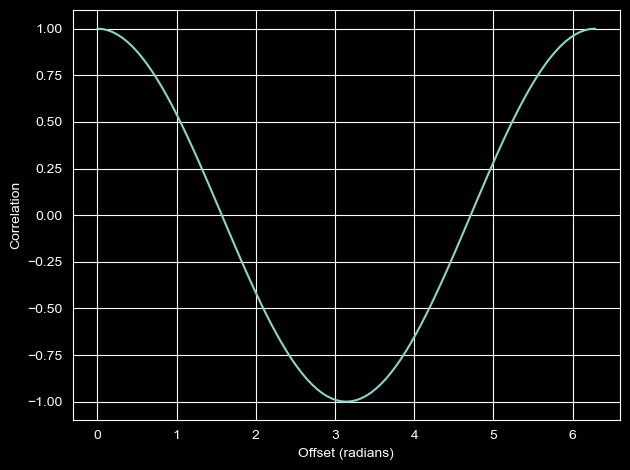

In [8]:
offsets = np.linspace(0, PI2, 101)

corrs = []
for offset in offsets:
    wave2 = make_sine(offset)
    corr = np.corrcoef(wave1.ys, wave2.ys)[0, 1]
    corrs.append(corr)
    
plt.plot(offsets, corrs)
decorate(xlabel='Offset (radians)',
         ylabel='Correlation')

Ця крива є косинусом.
Далі ми обчислимо послідовні кореляції для різних видів шуму.

In [9]:
def serial_corr(wave, lag=1):
    N = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:N-lag]
    corr = np.corrcoef(y1, y2)[0, 1]
    return corr

Ми очікуємо, що некорельований шум буде... ну... некорельованим.

In [10]:
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
serial_corr(wave)

np.float64(-0.004526534014770712)

Як і очікувалося, серійна кореляція близька до 0.

У броунівському шумі кожне значення є сумою попереднього значення та випадкового «кроку», тому ми очікуємо сильної серійної кореляції:

In [11]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
serial_corr(wave)

np.float64(0.9991344043959512)

Фактично, кореляція близька до 1.

Оскільки рожевий шум знаходиться між білим та броунівським, ми очікуємо проміжної кореляції.

In [12]:
from thinkdsp import PinkNoise

signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5, framerate=11025)
serial_corr(wave)

np.float64(0.8380059150673573)

І ми отримуємо те, що очікували.

Тепер ми можемо побудувати графік послідовної кореляції як функції параметра рожевого шуму $\beta$.

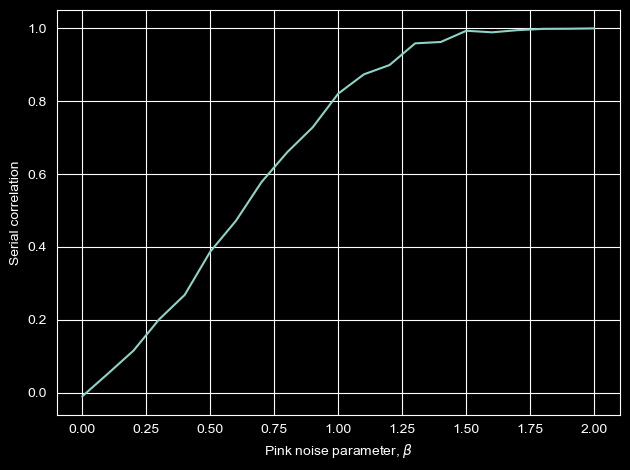

In [13]:
np.random.seed(19)

betas = np.linspace(0, 2, 21)
corrs = []

for beta in betas:
    signal =  PinkNoise(beta=beta)
    wave = signal.make_wave(duration=1.0, framerate=11025)
    corr = serial_corr(wave)
    corrs.append(corr)
    
plt.plot(betas, corrs)
decorate(xlabel=r'Pink noise parameter, $\beta$',
         ylabel='Serial correlation')

Функція автокореляції викликає `serial_corr` з різними значеннями `lag`.

In [14]:
def autocorr(wave):
    """Computes and plots the autocorrelation function.

    wave: Wave
    
    returns: tuple of sequences (lags, corrs)
    """
    lags = np.arange(len(wave.ys)//2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

Тепер ми можемо побудувати графік автокореляції для рожевого шуму з різними значеннями $\beta$.

In [15]:
def plot_pink_autocorr(beta, label):
    signal = PinkNoise(beta=beta)
    wave = signal.make_wave(duration=1.0, framerate=10000)
    lags, corrs = autocorr(wave)
    plt.plot(lags, corrs, label=label)

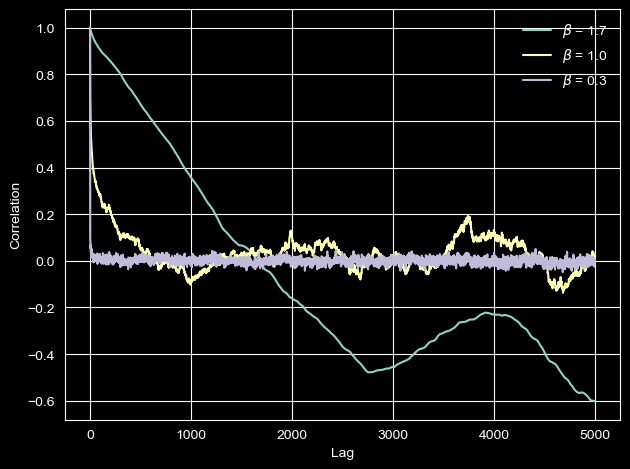

In [16]:
np.random.seed(19)

for beta in [1.7, 1.0, 0.3]:
    label = r'$\beta$ = %.1f' % beta
    plot_pink_autocorr(beta, label)

decorate(xlabel='Lag', 
         ylabel='Correlation')

Для низьких значень $\beta$ автокореляційна функція швидко спадає. Зі збільшенням $\beta$ рожевий шум демонструє більш довгострокову залежність.

Тепер давайте дослідимо використання автокореляції для відстеження висоти тону.
Я завантажу запис того, як хтось співає чірп:

In [17]:
from thinkdsp import read_wave

wave = read_wave('28042__bcjordan__voicedownbew.wav')
wave.normalize()
wave.make_audio()

Спектр показує нам, які частоти присутні, але для чірпів частотні компоненти розмиті в певному діапазоні:

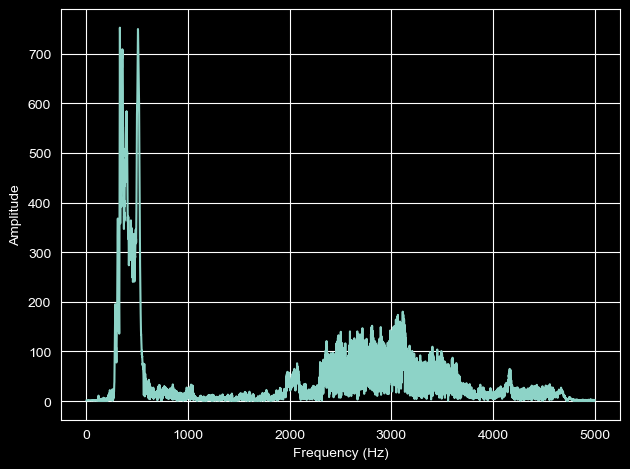

In [18]:
spectrum = wave.make_spectrum()
spectrum.plot(high=5000)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

Спектрограма дає краще уявлення про те, як компоненти змінюються з часом:

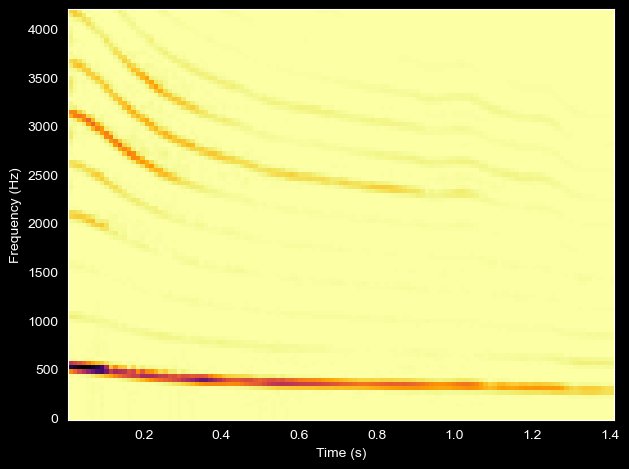

In [19]:
spectro = wave.make_spectrogram(seg_length=1024)
spectro.plot(high=4200)
decorate(xlabel='Time (s)', 
                 ylabel='Frequency (Hz)')

Ми чітко бачимо основну частоту, починаючи з 500 Гц і знижуючись. Також видно деякі гармоніки.

Щоб відстежити основну частоту, можна взяти короткий проміжок часу:

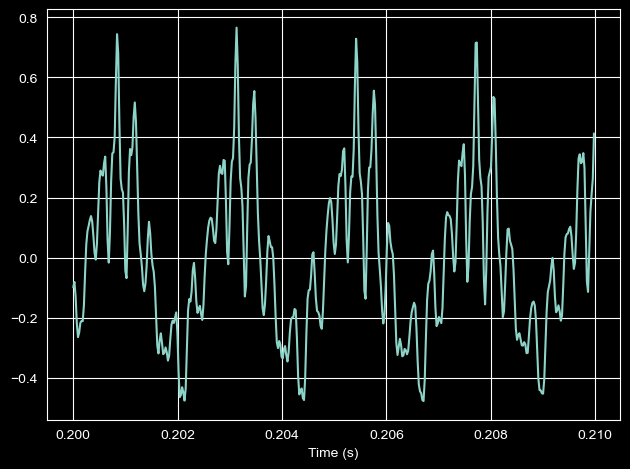

In [20]:
duration = 0.01
segment = wave.segment(start=0.2, duration=duration)
segment.plot()
decorate(xlabel='Time (s)')

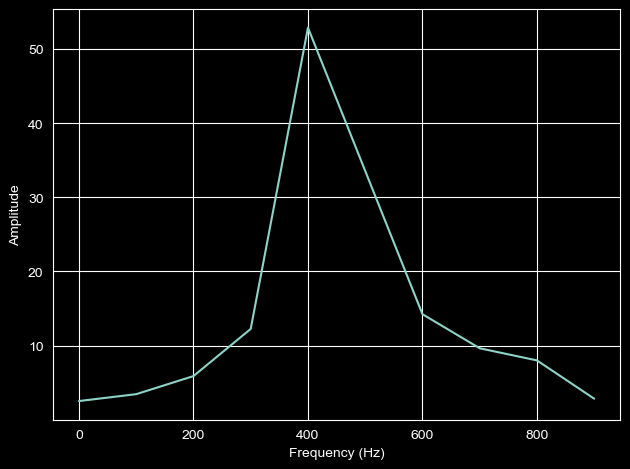

In [21]:
spectrum = segment.make_spectrum()
spectrum.plot(high=1000)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

Спектр показує чіткий пік поблизу 400 Гц, але ми не можемо отримати дуже точну оцінку частоти, частково тому, що пік розмитий, а частково тому, що навіть якби це був ідеальний сплеск, роздільна здатність за частотою не дуже добра.

In [22]:
len(segment), segment.framerate, spectrum.freq_res

(441, 44100, 100.22727272727273)

Кожен елемент спектру охоплює діапазон 100 Гц, тому ми не можемо отримати точну оцінку основної частоти.

Для сигналів, які є принаймні приблизно періодичними, ми можемо зробити краще, оцінивши тривалість періоду.

Наступна функція відтворює сегмент та зміщену версію сегмента, а також обчислює кореляцію між ними:

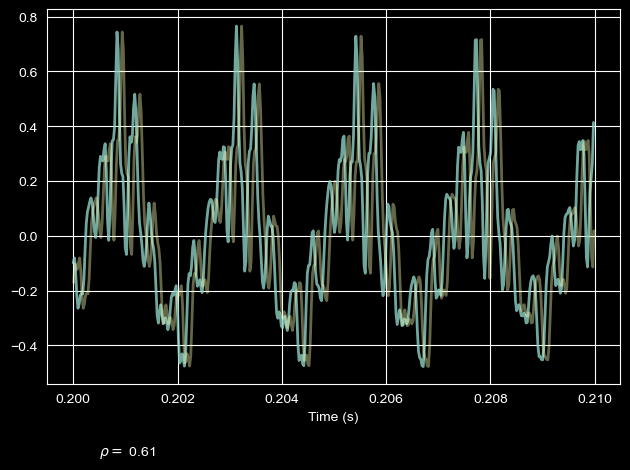

In [23]:
def plot_shifted(wave, offset=0.001, start=0.2):
    segment1 = wave.segment(start=start, duration=0.01)
    segment1.plot(linewidth=2, alpha=0.8)

    # start earlier and then shift times to line up
    segment2 = wave.segment(start=start-offset, duration=0.01)
    segment2.shift(offset)
    segment2.plot(linewidth=2, alpha=0.4)

    corr = segment1.corr(segment2)
    text = r'$\rho =$ %.2g' % corr
    plt.text(segment1.start+0.0005, -0.8, text)
    decorate(xlabel='Time (s)')

plot_shifted(wave, 0.0001)

При невеликому зсуві сегменти все ще помірно корелюють. Зі збільшенням зсуву кореляція на деякий час падає, потім знову зростає, досягаючи піку, коли зсув дорівнює періоду сигналу.

Ви можете використовувати таку взаємодію для пошуку зсуву, який максимізує кореляцію:

In [24]:
end = 0.004
slider1 = widgets.FloatSlider(min=0, max=end, step=end/40, value=0)
slider2 = widgets.FloatSlider(min=0.1, max=0.5, step=0.05, value=0.2)
interact(plot_shifted, wave=fixed(wave), offset=slider1, start=slider2);

interactive(children=(FloatSlider(value=0.0, description='offset', max=0.004, step=0.0001), FloatSlider(value=…

Функція `autocorr` автоматизує цей процес, обчислюючи кореляцію для кожного можливого затримки, аж до половини довжини хвилі.

На наступному рисунку показано цю автокореляцію як функцію затримки:

In [25]:
wave = read_wave('28042__bcjordan__voicedownbew.wav')
wave.normalize()
duration = 0.01
segment = wave.segment(start=0.2, duration=duration)

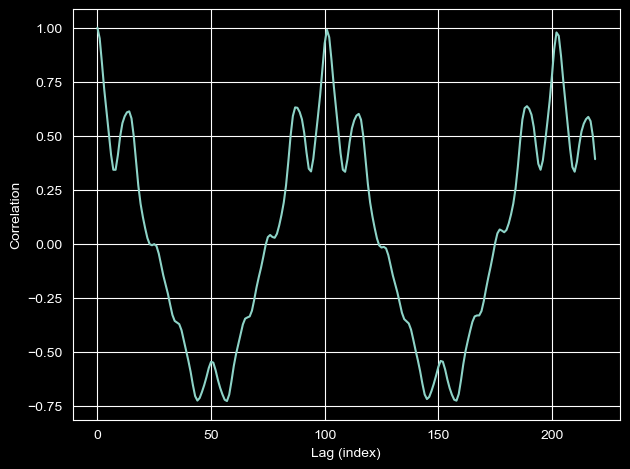

In [26]:
lags, corrs = autocorr(segment)
plt.plot(lags, corrs)
decorate(xlabel='Lag (index)', ylabel='Correlation')

Перший пік (відмінний від 0) близький до lag=100.

Ми можемо використовувати `argmax`, щоб знайти індекс цього піку:

In [27]:
low, high = 90, 110
lag = np.array(corrs[low:high]).argmax() + low
lag

np.int64(101)

Ми можемо перетворити індекс на час у секундах:

In [28]:
period = lag / segment.framerate
period

np.float64(0.002290249433106576)

Враховуючи період у секундах, ми можемо обчислити частоту:

In [29]:
frequency = 1 / period
frequency

np.float64(436.63366336633663)

Це має бути кращою оцінкою основної частоти. Ми можемо приблизно визначити роздільну здатність цієї оцінки, обчисливши, наскільки ми будемо відхилятися, якби індекс був відхилений на 1:

In [30]:
segment.framerate / 102, segment.framerate / 100

(432.3529411764706, 441.0)

Діапазон менше 10 Гц.

Функція, яку я написав для обчислення автокореляцій, повільна; `np.correlate` набагато швидша.

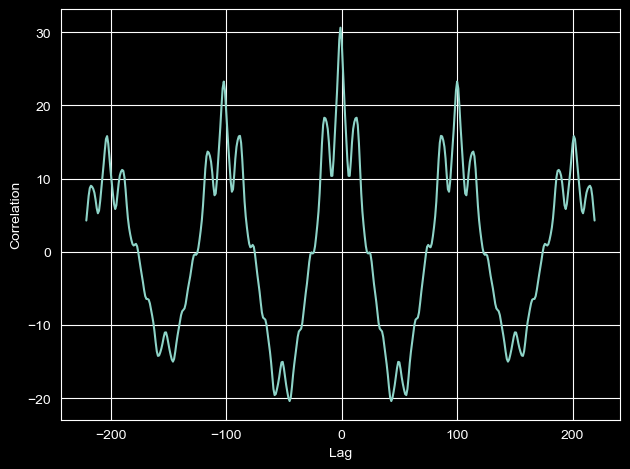

In [31]:
N = len(segment)
corrs2 = np.correlate(segment.ys, segment.ys, mode='same')
lags = np.arange(-N//2, N//2)
plt.plot(lags, corrs2)
decorate(xlabel='Lag', ylabel='Correlation')

`np.correlate` обчислює кореляції для позитивних та негативних затримок, тому lag=0 знаходиться посередині. Для наших цілей нас цікавлять лише позитивні затримки.

Також `np.correlate` не враховує той факт, що кількість елементів, що перекриваються, змінюється зі збільшенням затримки.

Наступний код вибирає другу половину результатів та вносить корекції на довжину перекриття:

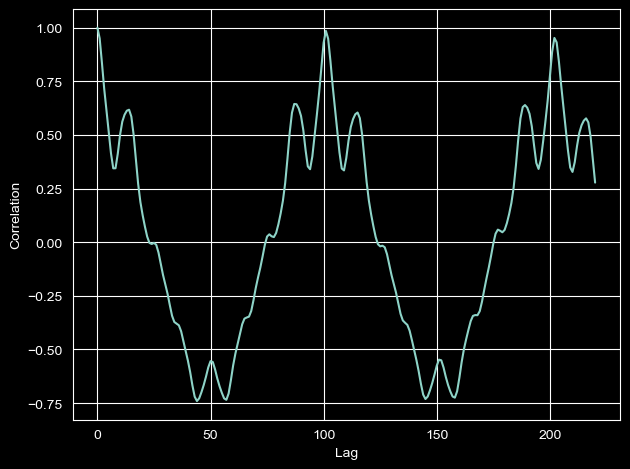

In [32]:
N = len(corrs2)
lengths = range(N, N//2, -1)

half = corrs2[N//2:].copy()
half /= lengths
half /= half[0]
plt.plot(half)
decorate(xlabel='Lag', ylabel='Correlation')

Тепер результат схожий на той, що ми обчислили раніше.

Якщо ми зобразимо результати, обчислені NumPy та моєю реалізацією, вони візуально схожі. Вони не зовсім ідентичні, оскільки моя версія та їхня нормалізовані по-різному.

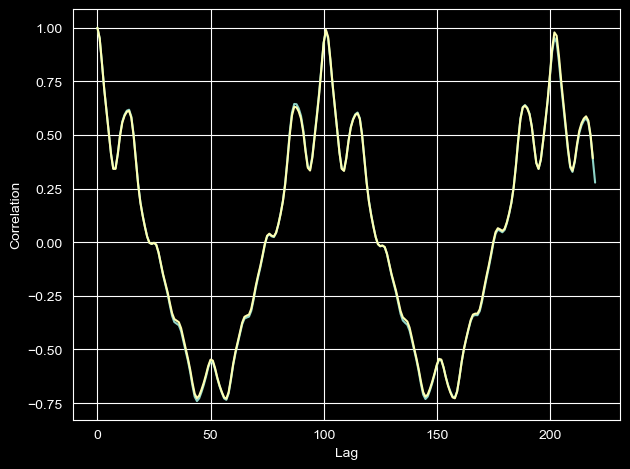

In [33]:
plt.plot(half)
plt.plot(corrs)
decorate(xlabel='Lag', ylabel='Correlation')

Різниця між реалізацією NumPy та моєю становить менше 0,02 для більшої частини діапазону.

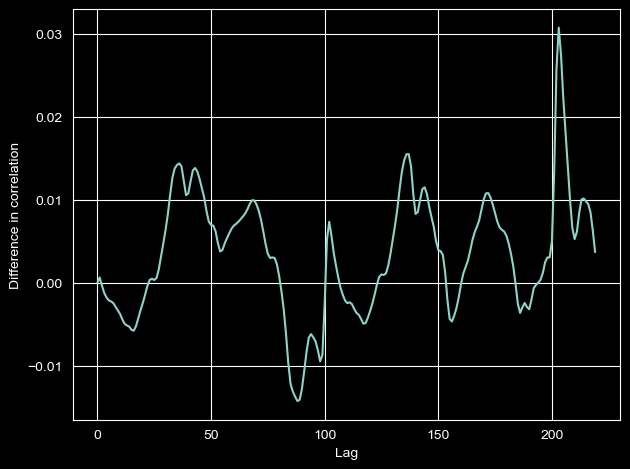

In [34]:
diff = corrs - half[:-1]
plt.plot(diff)
decorate(xlabel='Lag', ylabel='Difference in correlation')